# Лабораторная работа №4.3

**Студент:** Тавуз Мохамад  
**Группа:** ИУ5И-22М  
**Вариант:** 2

**Тема:** Решение задач многоэкстремальной оптимизации


In [13]:
# Импорт необходимых библиотек для выполнения лабораторной работы

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from scipy.optimize import minimize
from scipy.spatial.distance import cdist

np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


## Решение задачи многоэкстремальной оптимизации методом мультистарта

В данном разделе выполняется решение задачи многоэкстремальной оптимизации для функции Шекеля.  
Для выбранного варианта задаются параметры функции и область допустимых значений переменных.  
Далее выполняется локальная оптимизация из одной начальной точки, после чего применяется метод случайного мультистарта с несколькими начальными точками.

In [14]:
# Задание параметров варианта и определение функции Шекеля

variant = 2

alpha = 2
beta = 8

a = np.array([1.0, 1.0, 1.0])
b = np.array([3.0, 3.0, 3.0])
c = np.array([2.0, 2.0, 2.0])

lower_bound = alpha
upper_bound = beta
n = 3

def shekel_function(x):
    x = np.array(x, dtype=float)
    value = 0.0

    for i in range(n):
        inner_sum = 0.0
        for j in range(n):
            inner_sum += a[j] * (x[j] - b[j]) ** 2
        value += 1.0 / (inner_sum + c[i])

    return -value

x_test = np.array([3.0, 3.0, 3.0])
f_test = shekel_function(x_test)

print("Variant:", variant)
print("alpha =", alpha)
print("beta =", beta)
print("a =", a)
print("b =", b)
print("c =", c)
print("Dimension n =", n)
print("Test point:", x_test)
print("Function value at test point:", f_test)

Variant: 2
alpha = 2
beta = 8
a = [1. 1. 1.]
b = [3. 3. 3.]
c = [2. 2. 2.]
Dimension n = 3
Test point: [3. 3. 3.]
Function value at test point: -1.5


In [15]:
# Проверка допустимости точек в заданной области поиска

def is_feasible(x):
    x = np.array(x, dtype=float)
    return np.all(x >= lower_bound) and np.all(x <= upper_bound)

def boundary_violation(x):
    x = np.array(x, dtype=float)
    lower_violation = np.maximum(lower_bound - x, 0)
    upper_violation = np.maximum(x - upper_bound, 0)
    return np.sum(lower_violation ** 2 + upper_violation ** 2)

test_points = [
    np.array([3.0, 3.0, 3.0]),
    np.array([2.0, 2.0, 2.0]),
    np.array([8.0, 8.0, 8.0]),
    np.array([1.0, 3.0, 3.0]),
    np.array([9.0, 3.0, 3.0])
]

for point in test_points:
    print("Point:", point)
    print("f(x):", shekel_function(point))
    print("Boundary violation:", boundary_violation(point))
    print("Feasible:", is_feasible(point))
    print("-" * 50)

Point: [3. 3. 3.]
f(x): -1.5
Boundary violation: 0.0
Feasible: True
--------------------------------------------------
Point: [2. 2. 2.]
f(x): -0.6000000000000001
Boundary violation: 0.0
Feasible: True
--------------------------------------------------
Point: [8. 8. 8.]
f(x): -0.03896103896103896
Boundary violation: 0.0
Feasible: True
--------------------------------------------------
Point: [1. 3. 3.]
f(x): -0.5
Boundary violation: 1.0
Feasible: False
--------------------------------------------------
Point: [9. 3. 3.]
f(x): -0.07894736842105263
Boundary violation: 1.0
Feasible: False
--------------------------------------------------


In [16]:
# Выполнение локальной оптимизации функции Шекеля из одной начальной точки

bounds = [(lower_bound, upper_bound) for _ in range(n)]

x0_local = np.array([5.0, 5.0, 5.0])

start_time = time.time()

local_result = minimize(
    shekel_function,
    x0_local,
    method="L-BFGS-B",
    bounds=bounds,
    options={
        "maxiter": 1000,
        "ftol": 1e-12,
        "gtol": 1e-8
    }
)

local_time = time.time() - start_time

print("Initial point:", x0_local)
print("Optimization success:", local_result.success)
print("Message:", local_result.message)
print("Found point:", local_result.x)
print("Function value:", local_result.fun)
print("Number of iterations:", local_result.nit)
print("Execution time:", local_time)
print("Feasible:", is_feasible(local_result.x))
print("Boundary violation:", boundary_violation(local_result.x))

Initial point: [5. 5. 5.]
Optimization success: True
Message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Found point: [3. 3. 3.]
Function value: -1.5
Number of iterations: 5
Execution time: 0.0046427249908447266
Feasible: True
Boundary violation: 0.0


In [17]:
# Генерация случайных начальных точек для метода мультистарта

num_start_points = 30

initial_points = np.random.uniform(
    low=lower_bound,
    high=upper_bound,
    size=(num_start_points, n)
)

print("Number of generated start points:", num_start_points)
print("Search domain: [{}, {}]".format(lower_bound, upper_bound))
print("First five generated points:")
print(initial_points[:5])

print("\nFeasibility check for all generated points:")
print(np.all([is_feasible(point) for point in initial_points]))

Number of generated start points: 30
Search domain: [2, 8]
First five generated points:
[[4.24724071 7.70428584 6.39196365]
 [5.59195091 2.93611184 2.93596712]
 [2.34850167 7.19705687 5.60669007]
 [6.24843547 2.12350697 7.81945911]
 [6.99465584 3.27403466 3.0909498 ]]

Feasibility check for all generated points:
True


In [18]:
# Реализация метода случайного мультистарта для функции Шекеля

multistart_results = []

start_time = time.time()

for i, x0 in enumerate(initial_points, start=1):
    result = minimize(
        shekel_function,
        x0,
        method="L-BFGS-B",
        bounds=bounds,
        options={
            "maxiter": 1000,
            "ftol": 1e-12,
            "gtol": 1e-8
        }
    )

    multistart_results.append({
        "start_number": i,
        "initial_x1": x0[0],
        "initial_x2": x0[1],
        "initial_x3": x0[2],
        "found_x1": result.x[0],
        "found_x2": result.x[1],
        "found_x3": result.x[2],
        "f_value": result.fun,
        "iterations": result.nit,
        "success": result.success,
        "feasible": is_feasible(result.x)
    })

multistart_time = time.time() - start_time

multistart_df = pd.DataFrame(multistart_results)
best_multistart_result = multistart_df.loc[multistart_df["f_value"].idxmin()]

print("Random multistart completed")
print("Total execution time:", multistart_time)
print("\nBest result:")
print(best_multistart_result)

print("\nFirst ten rows of results table:")
display(multistart_df.head(10))

Random multistart completed
Total execution time: 0.17383384704589844

Best result:
start_number           3
initial_x1      2.348502
initial_x2      7.197057
initial_x3       5.60669
found_x1             3.0
found_x2             3.0
found_x3             3.0
f_value             -1.5
iterations             7
success             True
feasible            True
Name: 2, dtype: object

First ten rows of results table:


,start_number,initial_x1,initial_x2,initial_x3,found_x1,found_x2,found_x3,f_value,iterations,success,feasible
0,1,4.247241,7.704286,6.391964,3.0,3.0,3.0,-1.5,6,True,True
1,2,5.591951,2.936112,2.935967,3.0,3.0,3.0,-1.5,7,True,True
2,3,2.348502,7.197057,5.606690,3.0,3.0,3.0,-1.5,7,True,True
3,4,6.248435,2.123507,7.819459,3.0,3.0,3.0,-1.5,8,True,True
4,5,6.994656,3.274035,3.090950,3.0,3.0,3.0,-1.5,5,True,True
5,6,3.100427,3.825453,5.148539,3.0,3.0,3.0,-1.5,6,True,True
6,7,4.591670,3.747375,5.671117,3.0,3.0,3.0,-1.5,5,True,True
7,8,2.836963,3.752868,4.198171,3.0,3.0,3.0,-1.5,6,True,True
8,9,4.736420,6.711056,3.198043,3.0,3.0,3.0,-1.5,5,True,True
9,10,5.085407,5.554487,2.278702,3.0,3.0,3.0,-1.5,5,True,True


In [19]:
# Формирование итоговой таблицы для метода случайного мультистарта

multistart_summary = pd.DataFrame({
    "Method": ["Random Multistart"],
    "Number of start points": [num_start_points],
    "Best x1": [best_multistart_result["found_x1"]],
    "Best x2": [best_multistart_result["found_x2"]],
    "Best x3": [best_multistart_result["found_x3"]],
    "Best f(x)": [best_multistart_result["f_value"]],
    "Average iterations": [multistart_df["iterations"].mean()],
    "Successful runs": [multistart_df["success"].sum()],
    "Feasible solutions": [multistart_df["feasible"].sum()],
    "Execution time": [multistart_time]
})

display(multistart_summary)

,Method,Number of start points,Best x1,Best x2,Best x3,Best f(x),Average iterations,Successful runs,Feasible solutions,Execution time
0,Random Multistart,30,3.0,3.0,3.0,-1.5,5.933333,30,30,0.173834


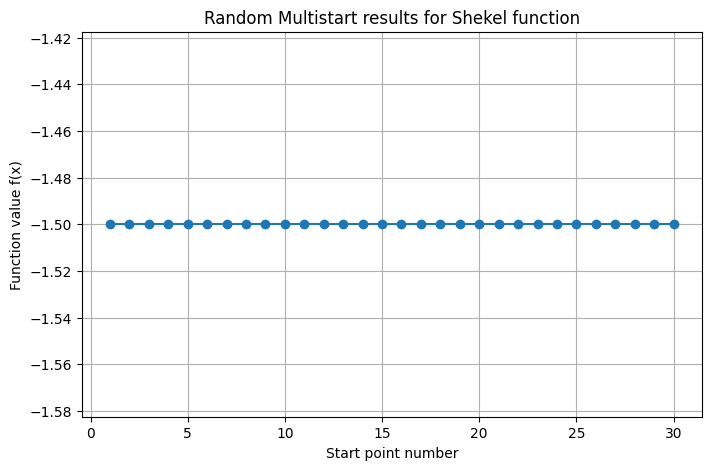

In [20]:
# Построение графика результатов метода случайного мультистарта

plt.figure(figsize=(8, 5))

plt.plot(
    multistart_df["start_number"],
    multistart_df["f_value"],
    marker="o"
)

plt.xlabel("Start point number")
plt.ylabel("Function value f(x)")
plt.title("Random Multistart results for Shekel function")
plt.grid(True)
plt.show()

In [21]:
# Кластеризация найденных точек методом ближайшего соседа

delta = 1e-4

found_points = multistart_df[["found_x1", "found_x2", "found_x3"]].values

clusters = []

for point in found_points:
    assigned = False

    for cluster in clusters:
        distances = np.linalg.norm(np.array(cluster) - point, axis=1)

        if np.min(distances) <= delta:
            cluster.append(point)
            assigned = True
            break

    if not assigned:
        clusters.append([point])

cluster_summary = []

for i, cluster in enumerate(clusters, start=1):
    cluster_array = np.array(cluster)
    center = cluster_array.mean(axis=0)

    cluster_summary.append({
        "Cluster": i,
        "Number of points": len(cluster),
        "Center x1": center[0],
        "Center x2": center[1],
        "Center x3": center[2]
    })

cluster_df = pd.DataFrame(cluster_summary)

print("Clustering radius delta:", delta)
print("Number of clusters:", len(clusters))
display(cluster_df)

Clustering radius delta: 0.0001
Number of clusters: 1


,Cluster,Number of points,Center x1,Center x2,Center x3
0,1,30,3.0,3.0,3.0


## Генетический алгоритм

В данном разделе выполняется реализация генетического алгоритма для решения задачи многоэкстремальной оптимизации.  
Генетический алгоритм использует популяцию возможных решений, функцию приспособленности, операции отбора, кроссинговера и мутации.  
В качестве целевой функции рассматривается функция из варианта 2, заданная на допустимой области \([0, 5]\).

In [22]:
# Задание параметров варианта для генетического алгоритма и определение целевой функции

ga_variant = 2

ga_n = 2
ga_alpha = 0
ga_beta = 5

ga_lower_bound = ga_alpha
ga_upper_bound = ga_beta

a_i = np.arange(1, 11, dtype=float)

a_ij = np.array([
    [1.0, 1.0],
    [2.0, 2.0],
    [3.0, 3.0],
    [4.0, 4.0],
    [5.0, 5.0],
    [1.0, 5.0],
    [5.0, 1.0],
    [2.0, 4.0],
    [4.0, 2.0],
    [3.0, 1.0]
])

def ga_objective_function(x):
    x = np.array(x, dtype=float)
    value = 0.0

    for i in range(10):
        distance_sum = np.sum((x - a_ij[i]) ** 2)
        value += 1.0 / (a_i[i] + distance_sum)

    return value

x_test_ga = np.array([2.5, 2.5])
f_test_ga = ga_objective_function(x_test_ga)

print("GA variant:", ga_variant)
print("Dimension n:", ga_n)
print("alpha =", ga_alpha)
print("beta =", ga_beta)
print("Test point:", x_test_ga)
print("Function value at test point:", f_test_ga)

GA variant: 2
Dimension n: 2
alpha = 0
beta = 5
Test point: [2.5 2.5]
Function value at test point: 1.4379986467497168


In [23]:
# Определение функции приспособленности и проверка допустимости решений

def ga_is_feasible(x):
    x = np.array(x, dtype=float)
    return np.all(x >= ga_lower_bound) and np.all(x <= ga_upper_bound)

def ga_boundary_violation(x):
    x = np.array(x, dtype=float)
    lower_violation = np.maximum(ga_lower_bound - x, 0)
    upper_violation = np.maximum(x - ga_upper_bound, 0)
    return np.sum(lower_violation ** 2 + upper_violation ** 2)

def fitness_function(x):
    return 1.0 / (1.0 + ga_objective_function(x))

ga_test_points = [
    np.array([2.5, 2.5]),
    np.array([0.0, 0.0]),
    np.array([5.0, 5.0]),
    np.array([-1.0, 2.0]),
    np.array([6.0, 2.0])
]

for point in ga_test_points:
    print("Point:", point)
    print("f(x):", ga_objective_function(point))
    print("Fitness:", fitness_function(point))
    print("Boundary violation:", ga_boundary_violation(point))
    print("Feasible:", ga_is_feasible(point))
    print("-" * 50)

Point: [2.5 2.5]
f(x): 1.4379986467497168
Fitness: 0.41017250002709266
Boundary violation: 0.0
Feasible: True
--------------------------------------------------
Point: [0. 0.]
f(x): 0.7086620515499825
Fitness: 0.5852532389847763
Boundary violation: 0.0
Feasible: True
--------------------------------------------------
Point: [5. 5.]
f(x): 0.7683320620391557
Fitness: 0.5655046478356831
Boundary violation: 0.0
Feasible: True
--------------------------------------------------
Point: [-1.  2.]
f(x): 0.5473054889153961
Fitness: 0.6462847880808353
Boundary violation: 1.0
Feasible: False
--------------------------------------------------
Point: [6. 2.]
f(x): 0.6182641432641434
Fitness: 0.6179460900511182
Boundary violation: 1.0
Feasible: False
--------------------------------------------------


In [24]:
# Формирование начальной популяции для генетического алгоритма

population_size = 40

initial_population = np.random.uniform(
    low=ga_lower_bound,
    high=ga_upper_bound,
    size=(population_size, ga_n)
)

initial_objective_values = np.array([
    ga_objective_function(individual) for individual in initial_population
])

initial_fitness_values = np.array([
    fitness_function(individual) for individual in initial_population
])

initial_population_df = pd.DataFrame({
    "x1": initial_population[:, 0],
    "x2": initial_population[:, 1],
    "f(x)": initial_objective_values,
    "fitness": initial_fitness_values
})

print("Population size:", population_size)
print("All individuals are feasible:", np.all([ga_is_feasible(individual) for individual in initial_population]))
print("Best initial objective value:", initial_objective_values.min())
print("Best initial individual:", initial_population[initial_objective_values.argmin()])

display(initial_population_df.head(10))

Population size: 40
All individuals are feasible: True
Best initial objective value: 0.7284890344501075
Best initial individual: [0.45144885 4.17651248]


,x1,x2,f(x),fitness
0,0.597971,3.566224,0.834830,0.545010
1,3.803925,2.806386,1.188337,0.456968
2,3.854836,2.468978,1.152557,0.464564
3,2.613664,2.137705,1.432151,0.411159
4,0.127096,0.539457,0.952882,0.512064
5,0.157146,3.182052,0.769269,0.565205
6,1.571780,2.542853,1.351270,0.425302
7,4.537832,1.246461,0.834666,0.545058
8,2.051915,3.777756,1.110441,0.473835
9,1.143991,0.384900,1.291546,0.436387


In [25]:
# Определение операторов отбора, кроссинговера и мутации

def selection(population, fitness_values):
    probabilities = fitness_values / np.sum(fitness_values)
    selected_indices = np.random.choice(
        len(population),
        size=len(population),
        replace=True,
        p=probabilities
    )
    return population[selected_indices]

def crossover(parent1, parent2, crossover_probability):
    if np.random.rand() < crossover_probability:
        c = np.random.rand()
        child1 = c * parent1 + (1 - c) * parent2
        child2 = (1 - c) * parent1 + c * parent2
        return child1, child2
    else:
        return parent1.copy(), parent2.copy()

def mutation(individual, mutation_probability):
    mutant = individual.copy()

    for j in range(len(mutant)):
        if np.random.rand() < mutation_probability:
            mutant[j] = np.random.uniform(ga_lower_bound, ga_upper_bound)

    return mutant

print("Selection, crossover and mutation operators are defined successfully")

Selection, crossover and mutation operators are defined successfully


In [26]:
# Реализация генетического алгоритма для решения задачи многоэкстремальной оптимизации

number_of_generations = 100
crossover_probability = 0.4
mutation_probability = 0.1

population = initial_population.copy()

best_history = []
mean_history = []

start_time = time.time()

for generation in range(number_of_generations):
    objective_values = np.array([
        ga_objective_function(individual) for individual in population
    ])

    fitness_values = np.array([
        fitness_function(individual) for individual in population
    ])

    best_index = np.argmin(objective_values)
    best_history.append(objective_values[best_index])
    mean_history.append(objective_values.mean())

    selected_population = selection(population, fitness_values)

    new_population = []

    for i in range(0, population_size, 2):
        parent1 = selected_population[i]
        parent2 = selected_population[(i + 1) % population_size]

        child1, child2 = crossover(parent1, parent2, crossover_probability)

        child1 = mutation(child1, mutation_probability)
        child2 = mutation(child2, mutation_probability)

        child1 = np.clip(child1, ga_lower_bound, ga_upper_bound)
        child2 = np.clip(child2, ga_lower_bound, ga_upper_bound)

        new_population.append(child1)
        new_population.append(child2)

    population = np.array(new_population[:population_size])

ga_execution_time = time.time() - start_time

final_objective_values = np.array([
    ga_objective_function(individual) for individual in population
])

best_final_index = np.argmin(final_objective_values)
best_ga_solution = population[best_final_index]
best_ga_value = final_objective_values[best_final_index]

print("Genetic algorithm completed")
print("Number of generations:", number_of_generations)
print("Population size:", population_size)
print("Crossover probability:", crossover_probability)
print("Mutation probability:", mutation_probability)
print("Best solution:", best_ga_solution)
print("Best function value:", best_ga_value)
print("Execution time:", ga_execution_time)
print("Feasible:", ga_is_feasible(best_ga_solution))
print("Boundary violation:", ga_boundary_violation(best_ga_solution))

Genetic algorithm completed
Number of generations: 100
Population size: 40
Crossover probability: 0.4
Mutation probability: 0.1
Best solution: [2.43884975 0.01823351]
Best function value: 0.8601526604558493
Execution time: 0.5495190620422363
Feasible: True
Boundary violation: 0.0


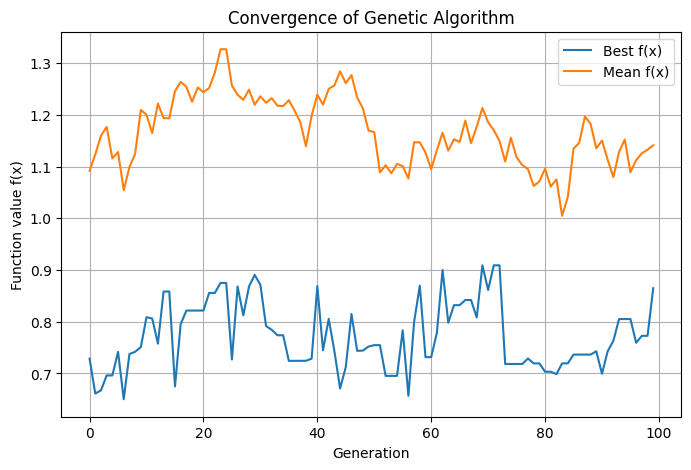

In [27]:
# Построение графика сходимости генетического алгоритма

plt.figure(figsize=(8, 5))

plt.plot(best_history, label="Best f(x)")
plt.plot(mean_history, label="Mean f(x)")

plt.xlabel("Generation")
plt.ylabel("Function value f(x)")
plt.title("Convergence of Genetic Algorithm")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Реализация генетического алгоритма с сохранением лучшей особи

elite_population = initial_population.copy()

elite_best_history = []
elite_mean_history = []

global_best_solution = None
global_best_value = np.inf

start_time = time.time()

for generation in range(number_of_generations):
    objective_values = np.array([
        ga_objective_function(individual) for individual in elite_population
    ])

    fitness_values = np.array([
        fitness_function(individual) for individual in elite_population
    ])

    best_index = np.argmin(objective_values)
    current_best_solution = elite_population[best_index].copy()
    current_best_value = objective_values[best_index]

    if current_best_value < global_best_value:
        global_best_value = current_best_value
        global_best_solution = current_best_solution.copy()

    elite_best_history.append(global_best_value)
    elite_mean_history.append(objective_values.mean())

    selected_population = selection(elite_population, fitness_values)

    new_population = [global_best_solution.copy()]

    while len(new_population) < population_size:
        parent_indices = np.random.choice(len(selected_population), size=2, replace=False)
        parent1 = selected_population[parent_indices[0]]
        parent2 = selected_population[parent_indices[1]]

        child1, child2 = crossover(parent1, parent2, crossover_probability)

        child1 = mutation(child1, mutation_probability)
        child2 = mutation(child2, mutation_probability)

        child1 = np.clip(child1, ga_lower_bound, ga_upper_bound)
        child2 = np.clip(child2, ga_lower_bound, ga_upper_bound)

        new_population.append(child1)
        if len(new_population) < population_size:
            new_population.append(child2)

    elite_population = np.array(new_population)

elite_ga_execution_time = time.time() - start_time

print("Genetic algorithm with elitism completed")
print("Number of generations:", number_of_generations)
print("Population size:", population_size)
print("Crossover probability:", crossover_probability)
print("Mutation probability:", mutation_probability)
print("Best solution:", global_best_solution)
print("Best function value:", global_best_value)
print("Execution time:", elite_ga_execution_time)
print("Feasible:", ga_is_feasible(global_best_solution))
print("Boundary violation:", ga_boundary_violation(global_best_solution))

Genetic algorithm with elitism completed
Number of generations: 100
Population size: 40
Crossover probability: 0.4
Mutation probability: 0.1
Best solution: [0.03476065 4.90832825]
Best function value: 0.5788257244560986
Execution time: 1.3790788650512695
Feasible: True
Boundary violation: 0.0


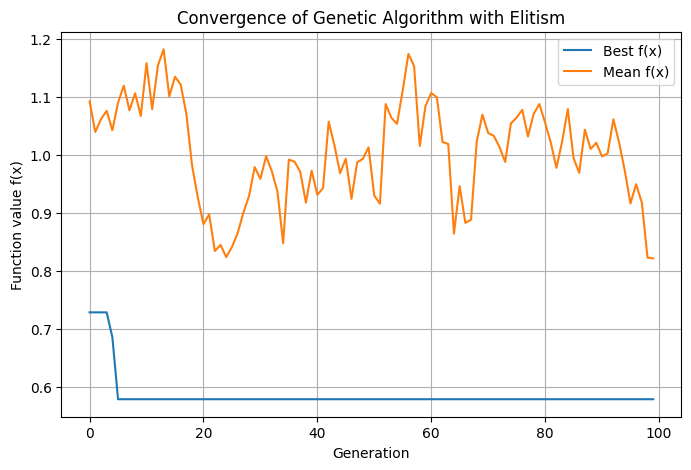

In [29]:
# Построение графика сходимости генетического алгоритма с сохранением лучшей особи

plt.figure(figsize=(8, 5))

plt.plot(elite_best_history, label="Best f(x)")
plt.plot(elite_mean_history, label="Mean f(x)")

plt.xlabel("Generation")
plt.ylabel("Function value f(x)")
plt.title("Convergence of Genetic Algorithm with Elitism")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Формирование итоговой сравнительной таблицы результатов

comparison_table = pd.DataFrame({
    "Method": [
        "Random Multistart",
        "Genetic Algorithm",
        "Genetic Algorithm with Elitism"
    ],
    "Best x1": [
        best_multistart_result["found_x1"],
        best_ga_solution[0],
        global_best_solution[0]
    ],
    "Best x2": [
        best_multistart_result["found_x2"],
        best_ga_solution[1],
        global_best_solution[1]
    ],
    "Best x3": [
        best_multistart_result["found_x3"],
        "-",
        "-"
    ],
    "Best f(x)": [
        best_multistart_result["f_value"],
        best_ga_value,
        global_best_value
    ],
    "Iterations / generations": [
        num_start_points,
        number_of_generations,
        number_of_generations
    ],
    "Execution time": [
        multistart_time,
        ga_execution_time,
        elite_ga_execution_time
    ],
    "Feasible": [
        is_feasible([
            best_multistart_result["found_x1"],
            best_multistart_result["found_x2"],
            best_multistart_result["found_x3"]
        ]),
        ga_is_feasible(best_ga_solution),
        ga_is_feasible(global_best_solution)
    ],
    "Boundary violation": [
        boundary_violation([
            best_multistart_result["found_x1"],
            best_multistart_result["found_x2"],
            best_multistart_result["found_x3"]
        ]),
        ga_boundary_violation(best_ga_solution),
        ga_boundary_violation(global_best_solution)
    ]
})

display(comparison_table)

,Method,Best x1,Best x2,Best x3,Best f(x),Iterations / generations,Execution time,Feasible,Boundary violation
0,Random Multistart,3.000000,3.000000,3.0,-1.500000,30,0.173834,True,0.0
1,Genetic Algorithm,2.438850,0.018234,-,0.860153,100,0.549519,True,0.0
2,Genetic Algorithm with Elitism,0.034761,4.908328,-,0.578826,100,1.379079,True,0.0
